
title: "M5 — LLM Prompting Evaluation with Google Gemini"

date: "2026-03-17"

author: "Person B"

project: "Sentimind — Mental Health Sentiment Analysis"

purpose: >
  Đánh giá khả năng phân loại cảm xúc sức khỏe tâm thần (zero-shot và few-shot)
  sử dụng Google Gemini 2.5 Flash / Pro thay thế cho OpenAI GPT,
  so sánh hiệu quả với BiLSTM baseline và BERTweet fine-tuned.

objectives:
  - Chạy inference zero-shot trên tập test với gemini-2.5-flash
  - Chạy inference few-shot (3-shot) và so sánh với zero-shot
  - Tính Accuracy, Macro F1, Weighted F1 và confusion matrix
  - Theo dõi chi phí API (token usage, USD estimate)
  - Xuất artifacts: llm_predictions.jsonl, llm_metrics.json, llm_cost_report.json
  - So sánh tổng hợp 3 model: BiLSTM vs BERTweet vs Gemini

milestone: M5

depends_on: "data/processed/test.csv (M2), GOOGLE_API_KEY env var"

outputs:
  - data/artifacts/llm_predictions.jsonl
  - data/artifacts/llm_metrics.json
  - data/artifacts/llm_cost_report.json
  - data/artifacts/llm_confusion_matrix.png

# M5 — LLM Prompting Evaluation: Google Gemini 2.5 Flash / Pro

> **Mục đích:** Đánh giá Google Gemini (2.5 Flash mặc định, có thể chuyển sang 2.5 Pro)
> cho bài toán phân loại sức khỏe tâm thần — zero-shot và few-shot.
> Kết quả được so sánh trực tiếp với BiLSTM (M3) và BERTweet (M4).

**Yêu cầu trước khi chạy:**
```bash
pip install google-genai>=1.0.0
export GOOGLE_API_KEY="<your-google-api-key>"
# Hoặc tạo file .env với: GOOGLE_API_KEY=...

In [6]:
%pip show google-genai
%pip install google-genai

Note: you may need to restart the kernel to use updated packages.
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 6.7 MB/s  0:00:00
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [google-genai] [google-genai]
Note: you may need to restart the kernel to use updated packages.


## 1. Thiết lập môi trường

In [7]:
import os
import sys
import json
import logging
from pathlib import Path

# Đưa thư mục gốc dự án vào Python path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

# Tải API key từ .env nếu có (optional, ưu tiên environment variable)
env_file = PROJECT_ROOT / ".env"
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if line.startswith("GOOGLE_API_KEY=") and "GOOGLE_API_KEY" not in os.environ:
            os.environ["GOOGLE_API_KEY"] = line.split("=", 1)[1].strip()
            print("GOOGLE_API_KEY loaded from .env")

# Kiểm tra API key
api_key = os.environ.get("GOOGLE_API_KEY", "")
if not api_key:
    print("⚠️  GOOGLE_API_KEY chưa được thiết lập.")
    print("   Chạy: export GOOGLE_API_KEY='<your-key>'  hoặc tạo file .env")
else:
    print(f"✅ GOOGLE_API_KEY đã có ({len(api_key)} ký tự)")

Project root: /home/sakana/Code/PTIT/NLP/sentimind
✅ GOOGLE_API_KEY đã có (39 ký tự)


## 2. Cấu hình model Gemini

In [8]:
import yaml

# Đọc config từ file
CONFIG_PATH = PROJECT_ROOT / "configs" / "llm_prompting.yaml"
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# --- Tuỳ chỉnh tại đây ---
# Chọn model: "gemini-2.5-flash" (nhanh, rẻ) hoặc "gemini-2.5-pro" (chất lượng cao hơn)
cfg["generation"]["model"] = "gemini-2.5-flash"  # đổi thành "gemini-2.5-pro" nếu muốn

# Số lượng mẫu thử nghiệm (None = full test set, số nguyên = lấy mẫu)
SAMPLE_SIZE = 200   # để None nếu muốn chạy toàn bộ

# Mode: "zero_shot" hoặc "few_shot"
PROMPTING_MODE = "zero_shot"
# -------------------------

cfg["data"]["sample_size"] = SAMPLE_SIZE
cfg["prompting"]["mode"] = PROMPTING_MODE

print(f"Model      : {cfg['generation']['model']}")
print(f"Mode       : {PROMPTING_MODE}")
print(f"Sample size: {SAMPLE_SIZE or 'full test set'}")
print(f"Budget cap : ${cfg['cost']['budget_cap_usd']} USD")
print(f"Est. cost  : ~${SAMPLE_SIZE * cfg['cost']['input_price_per_1k'] * 0.2:.4f} USD (approx)")

Model      : gemini-2.5-flash
Mode       : zero_shot
Sample size: 200
Budget cap : $5.0 USD
Est. cost  : ~$0.0030 USD (approx)


## 3. Kiểm tra kết nối Gemini API (smoke test)

In [9]:
from google import genai
from google.genai import types as gentypes

_smoke_client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])
_smoke_resp = _smoke_client.models.generate_content(
    model=cfg["generation"]["model"],
    contents=[gentypes.Content(role="user", parts=[gentypes.Part(text="Reply with one word: ready")])],
    config=gentypes.GenerateContentConfig(max_output_tokens=8, temperature=0.0),
)
print(f"✅ API smoke test OK — response: {_smoke_resp.text!r}")
print(f"   Input tokens : {_smoke_resp.usage_metadata.prompt_token_count}")
print(f"   Output tokens: {_smoke_resp.usage_metadata.candidates_token_count}")

✅ API smoke test OK — response: None
   Input tokens : 7
   Output tokens: None


## 4. Chạy zero-shot inference

In [15]:
import importlib
import random
import json as _json
import pandas as pd
from tqdm import tqdm

# Force-reload llm_client so any source changes are picked up
import src.models.llm_client as _llm_mod
importlib.reload(_llm_mod)
from src.models.llm_client import LLMClient, _FEW_SHOT_EXAMPLES

import src.utils.metrics as _metrics_mod
importlib.reload(_metrics_mod)
from src.utils.metrics import compute_metrics, save_confusion_matrix_plot, save_metrics

ARTIFACTS_DIR = PROJECT_ROOT / "data" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

label_map = {int(k): v for k, v in cfg["label_map"].items()}
gen_cfg = cfg["generation"]
cost_cfg = cfg["cost"]

# --- Khởi tạo LLMClient (max_tokens=1024 để đủ budget sau thinking) ---
llm_client = LLMClient(
    model=gen_cfg["model"],
    api_key_env="GOOGLE_API_KEY",
    temperature=gen_cfg.get("temperature", 0.0),
    max_tokens=1024,
    request_timeout=gen_cfg.get("request_timeout", 60),
    max_retries=gen_cfg.get("max_retries", 3),
    input_price_per_1k=cost_cfg.get("input_price_per_1k", 0.000075),
    output_price_per_1k=cost_cfg.get("output_price_per_1k", 0.000300),
    budget_cap_usd=cost_cfg.get("budget_cap_usd", 5.0),
)

# --- Load & sample test data ---
df_test = pd.read_csv(PROJECT_ROOT / cfg["data"]["test_path"])
if SAMPLE_SIZE and SAMPLE_SIZE < len(df_test):
    rng = random.Random(cfg["data"].get("sample_seed", 42))
    indices = rng.sample(range(len(df_test)), SAMPLE_SIZE)
    df_test = df_test.iloc[indices].reset_index(drop=True)

print(f"Model      : {llm_client.model}")
print(f"Test rows  : {len(df_test)}")
print(f"Budget cap : ${llm_client.cost.budget_cap_usd} USD")

# --- Zero-shot inference loop ---
predictions_zs = []
jsonl_path = ARTIFACTS_DIR / cfg["output"]["predictions_name"]
parse_errors_zs = 0

with open(jsonl_path, "w", encoding="utf-8") as fout:
    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="zero-shot classify"):
        try:
            pred = llm_client.classify(str(row["text"]), label_map, mode="zero_shot")
        except RuntimeError as exc:
            print(f"\n⚠️  Budget exceeded: {exc}")
            break
        if pred.parse_error:
            parse_errors_zs += 1
        fout.write(_json.dumps({
            "text": pred.text,
            "true_label_id": int(row["label_id"]),
            "predicted_label": pred.predicted_label,
            "predicted_label_id": pred.predicted_label_id,
            "confidence": pred.confidence,
            "explanation": pred.explanation,
            "prompt_tokens": pred.prompt_tokens,
            "completion_tokens": pred.completion_tokens,
            "latency_s": round(pred.latency_s, 3),
            "parse_error": pred.parse_error,
        }, ensure_ascii=False) + "\n")
        predictions_zs.append(pred)

print(f"\n✅ Zero-shot done.  Parse errors: {parse_errors_zs}/{len(predictions_zs)}")
print(f"   Est. cost     : ${llm_client.cost.estimated_cost_usd:.6f} USD")

# --- Tính metrics & lưu artifacts ---
valid_zs = [
    (int(df_test.iloc[i]["label_id"]), p.predicted_label_id)
    for i, p in enumerate(predictions_zs)
    if not p.parse_error and p.predicted_label_id != -1
]
if valid_zs:
    y_true_zs, y_pred_zs = zip(*valid_zs)
    metrics_zs = compute_metrics(
        list(y_true_zs), list(y_pred_zs),
        label_names=label_map, model_name="llm", split="test",
    )
    metrics_zs.update({
        "prompting_mode": "zero_shot",
        "model": gen_cfg["model"],
        "total_samples": len(predictions_zs),
        "valid_samples": len(valid_zs),
        "parse_errors": parse_errors_zs,
    })
    save_metrics(metrics_zs, ARTIFACTS_DIR / cfg["output"]["metrics_name"])
    save_confusion_matrix_plot(
        metrics_zs["confusion_matrix"],
        label_names=label_map,
        title=f"LLM {gen_cfg['model']} (zero-shot) — Test",
        path=ARTIFACTS_DIR / cfg["output"]["confusion_matrix_name"],
    )
    cost_report = llm_client.cost.to_dict()
    cost_report.update({"model": gen_cfg["model"], "prompting_mode": "zero_shot"})
    with open(ARTIFACTS_DIR / cfg["output"]["cost_report_name"], "w") as f:
        _json.dump(cost_report, f, indent=2)
    print(f"   Accuracy      : {metrics_zs['accuracy']:.4f}")
    print(f"   Macro F1      : {metrics_zs['macro_f1']:.4f}")
    print(f"   Weighted F1   : {metrics_zs['weighted_f1']:.4f}")
else:
    print("❌ Không có dự đoán hợp lệ.")

Model      : gemini-2.5-flash
Test rows  : 200
Budget cap : $5.0 USD


zero-shot classify: 100%|██████████| 200/200 [04:26<00:00,  1.33s/it]


✅ Zero-shot done.  Parse errors: 0/200
   Est. cost     : $0.009019 USD
   Accuracy      : 0.6600
   Macro F1      : 0.6175
   Weighted F1   : 0.6550


## 5. Chạy few-shot inference (3-shot)

In [14]:
# --- DIAGNOSTIC: inspect raw responses for parse errors ---
failed = [p for p in predictions_zs if p.parse_error]
print(f"Parse errors: {len(failed)}/{len(predictions_zs)}")
for p in failed[:5]:
    print("\nraw_response:", repr(p.raw_response[:400]))

Parse errors: 114/200

raw_response: '```json\n{\n  "label":'

raw_response: '```json\n{\n  "label": "'

raw_response: '```json\n{\n  "label":'

raw_response: '```json\n{\n  "label": "Stress'

raw_response: '```json\n{\n  "label": "'


In [16]:
few_shot_examples = _FEW_SHOT_EXAMPLES[: cfg["prompting"].get("num_few_shot_examples", 3)]

llm_client_fs = LLMClient(
    model=gen_cfg["model"],
    api_key_env="GOOGLE_API_KEY",
    temperature=gen_cfg.get("temperature", 0.0),
    max_tokens=1024,
    request_timeout=gen_cfg.get("request_timeout", 60),
    max_retries=gen_cfg.get("max_retries", 3),
    input_price_per_1k=cost_cfg.get("input_price_per_1k", 0.000075),
    output_price_per_1k=cost_cfg.get("output_price_per_1k", 0.000300),
    budget_cap_usd=cost_cfg.get("budget_cap_usd", 5.0),
)

predictions_fs = []
fs_jsonl_path = ARTIFACTS_DIR / "llm_fewshot_predictions.jsonl"
parse_errors_fs = 0

with open(fs_jsonl_path, "w", encoding="utf-8") as fout:
    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="few-shot (3-shot)"):
        try:
            pred = llm_client_fs.classify(
                str(row["text"]), label_map, mode="few_shot",
                few_shot_examples=few_shot_examples,
            )
        except RuntimeError as exc:
            print(f"\n⚠️  Budget exceeded: {exc}")
            break
        if pred.parse_error:
            parse_errors_fs += 1
        fout.write(_json.dumps({
            "text": pred.text,
            "true_label_id": int(row["label_id"]),
            "predicted_label": pred.predicted_label,
            "predicted_label_id": pred.predicted_label_id,
            "confidence": pred.confidence,
            "explanation": pred.explanation,
            "prompt_tokens": pred.prompt_tokens,
            "completion_tokens": pred.completion_tokens,
            "latency_s": round(pred.latency_s, 3),
            "parse_error": pred.parse_error,
        }, ensure_ascii=False) + "\n")
        predictions_fs.append(pred)

print(f"\n✅ Few-shot done.   Parse errors: {parse_errors_fs}/{len(predictions_fs)}")
print(f"   Est. cost     : ${llm_client_fs.cost.estimated_cost_usd:.6f} USD")

valid_fs = [
    (int(df_test.iloc[i]["label_id"]), p.predicted_label_id)
    for i, p in enumerate(predictions_fs)
    if not p.parse_error and p.predicted_label_id != -1
]
if valid_fs:
    y_true_fs, y_pred_fs = zip(*valid_fs)
    metrics_fs = compute_metrics(
        list(y_true_fs), list(y_pred_fs),
        label_names=label_map, model_name="llm_fewshot", split="test",
    )
    metrics_fs.update({"prompting_mode": "few_shot", "model": gen_cfg["model"]})
    save_metrics(metrics_fs, ARTIFACTS_DIR / "llm_fewshot_metrics.json")
    save_confusion_matrix_plot(
        metrics_fs["confusion_matrix"],
        label_names=label_map,
        title=f"LLM {gen_cfg['model']} (3-shot) — Test",
        path=ARTIFACTS_DIR / "llm_fewshot_confusion_matrix.png",
    )
    print(f"   Accuracy      : {metrics_fs['accuracy']:.4f}")
    print(f"   Macro F1      : {metrics_fs['macro_f1']:.4f}")
    print(f"   Weighted F1   : {metrics_fs['weighted_f1']:.4f}")
    if "metrics_zs" in dir():
        print(f"\n{'Mode':<16} {'Accuracy':>10} {'Macro F1':>10} {'Wtd F1':>10}")
        print("-" * 50)
        print(f"{'zero_shot':<16} {metrics_zs['accuracy']:>10.4f} {metrics_zs['macro_f1']:>10.4f} {metrics_zs['weighted_f1']:>10.4f}")
        print(f"{'few_shot (3)':<16} {metrics_fs['accuracy']:>10.4f} {metrics_fs['macro_f1']:>10.4f} {metrics_fs['weighted_f1']:>10.4f}")
else:
    print("❌ Không có dự đoán hợp lệ.")

few-shot (3-shot): 100%|██████████| 200/200 [03:56<00:00,  1.18s/it]


✅ Few-shot done.   Parse errors: 0/200
   Est. cost     : $0.010334 USD
   Accuracy      : 0.6150
   Macro F1      : 0.5583
   Weighted F1   : 0.6090

Mode               Accuracy   Macro F1     Wtd F1
--------------------------------------------------
zero_shot            0.6600     0.6175     0.6550
few_shot (3)         0.6150     0.5583     0.6090


## 6. Xem kết quả metrics và chi phí

In [ ]:
import pandas as pd
from IPython.display import display

artifacts_dir = PROJECT_ROOT / "data" / "artifacts"

# --- Metrics ---
metrics_path = artifacts_dir / "llm_metrics.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        llm_metrics = json.load(f)

    print("=" * 50)
    print(f"  Model   : {llm_metrics.get('model', cfg['generation']['model'])}")
    print(f"  Mode    : {llm_metrics.get('prompting_mode', PROMPTING_MODE)}")
    print(f"  Samples : {llm_metrics.get('valid_samples')} / {llm_metrics.get('total_samples')}")
    print(f"  Accuracy: {llm_metrics['accuracy']:.4f}")
    print(f"  Macro F1: {llm_metrics['macro_f1']:.4f}")
    print(f"  Wtd  F1 : {llm_metrics['weighted_f1']:.4f}")
    print("=" * 50)

    # Per-class breakdown
    per_class = llm_metrics.get("per_class", {})
    if per_class:
        rows = [
            {
                "Class": cls,
                "Precision": v["precision"],
                "Recall": v["recall"],
                "F1": v["f1"],
                "Support": v["support"],
            }
            for cls, v in per_class.items()
        ]
        display(pd.DataFrame(rows).set_index("Class").round(4))
else:
    print("llm_metrics.json không tồn tại — chạy cell 4 trước.")

# --- Cost report ---
cost_path = artifacts_dir / "llm_cost_report.json"
if cost_path.exists():
    with open(cost_path) as f:
        cost = json.load(f)
    print(f"\nCost Report:")
    print(f"  Prompt tokens    : {cost['total_prompt_tokens']:,}")
    print(f"  Completion tokens: {cost['total_completion_tokens']:,}")
    print(f"  Estimated cost   : ${cost['estimated_cost_usd']:.6f} USD")
    print(f"  Total requests   : {cost['total_requests']}")

  Model   : gemini-2.5-flash
  Mode    : zero_shot
  Samples : 200 / 200
  Accuracy: 0.6600
  Macro F1: 0.6175
  Wtd  F1 : 0.6550


,Precision,Recall,F1,Support
Class,,,,
Normal,0.8571,0.8235,0.8400,51
Depression,0.6500,0.4407,0.5253,59
Anxiety,0.5417,0.9286,0.6842,14
Bipolar,0.7778,0.7778,0.7778,9
Personality disorder,0.4286,0.4286,0.4286,7
Stress,0.3636,0.4444,0.4000,9
Suicidal,0.6167,0.7255,0.6667,51



Cost Report:
  Prompt tokens    : 69,685
  Completion tokens: 12,643
  Estimated cost   : $0.009019 USD
  Total requests   : 200


## 7. So sánh tổng hợp: BiLSTM vs BERTweet vs Gemini

In [ ]:
comparison_rows = []
metric_files = {
    "BiLSTM (M3)": "bilstm_metrics.json",
    "BERTweet (M4)": "bertweet_metrics.json",
    f"Gemini {cfg['generation']['model']} (M5)": "llm_metrics.json",
}

for model_name, fname in metric_files.items():
    fpath = artifacts_dir / fname
    if fpath.exists():
        with open(fpath) as f:
            m = json.load(f)
        comparison_rows.append(
            {
                "Model": model_name,
                "Accuracy": m["accuracy"],
                "Macro F1": m["macro_f1"],
                "Weighted F1": m["weighted_f1"],
            }
        )
    else:
        print(f"  {fname} not found — skipping.")

if comparison_rows:
    df_cmp = (
        pd.DataFrame(comparison_rows)
        .set_index("Model")
        .sort_values("Macro F1", ascending=False)
    )
    print("\n Bảng so sánh tổng hợp (sắp xếp theo Macro F1):\n")
    display(df_cmp.round(4))
else:
    print("Chưa có đủ artifact để so sánh.")


 Bảng so sánh tổng hợp (sắp xếp theo Macro F1):



,Accuracy,Macro F1,Weighted F1
Model,,,
BERTweet (M4),0.8155,0.7831,0.8167
BiLSTM (M3),0.7583,0.6936,0.7615
Gemini gemini-2.5-flash (M5),0.6600,0.6175,0.6550


## 8. Xem ví dụ dự đoán và phân tích lỗi

In [30]:
import jsonlines

LABEL_MAP = {int(k): v for k, v in cfg["label_map"].items()}

preds_path = artifacts_dir / "llm_predictions.jsonl"
if preds_path.exists():
    with jsonlines.open(preds_path) as reader:
        preds = list(reader)

    print(f"Tổng dự đoán: {len(preds)}")

    # Các dự đoán sai (worst errors)
    errors = [p for p in preds if p["true_label_id"] != p["predicted_label_id"] and not p["parse_error"]]
    print(f"Dự đoán sai : {len(errors)} ({100*len(errors)/len(preds):.1f}%)")

    # Hiển thị 5 ví dụ sai đầu tiên
    print("\n--- 5 lỗi tiêu biểu ---")
    for p in errors[:5]:
        true_lbl = LABEL_MAP.get(p["true_label_id"], "?")
        pred_lbl = p["predicted_label"]
        print(f"  True: {true_lbl:<22} | Pred: {pred_lbl:<22}")
        print(f"  Text: {p['text'][:80]}...")
        print(f"  Exp : {p['explanation'][:100]}")
        print()
else:
    print("llm_predictions.jsonl không tồn tại — chạy cell 4 trước.")

Tổng dự đoán: 200
Dự đoán sai : 68 (34.0%)

--- 5 lỗi tiêu biểu ---
  True: Depression             | Pred: Suicidal              
  Text: 21m. so. i have been feeling depressed, very anxious and very low the past while...
  Exp : The post explicitly mentions 'suicide line,' 'dark feelings,' 'hopeless alot,' and 'i just want the 

  True: Suicidal               | Pred: Stress                
  Text: hi what the fuck have i been doing with my life lately?...
  Exp : The post expresses frustration and self-questioning about life choices, which is indicative of stres

  True: Stress                 | Pred: Anxiety               
  Text: when it is his weekend off). he grumbles and yells only on his 'nervous' days. m...
  Exp : The post describes a pattern of grumbling and yelling on 'nervous' days, which suggests a recurring 

  True: Depression             | Pred: Suicidal              
  Text: life is just getting harder and harder i was homeless from 5 to 14 me and my lit...
  Exp : The

## 9. Vẽ confusion matrix

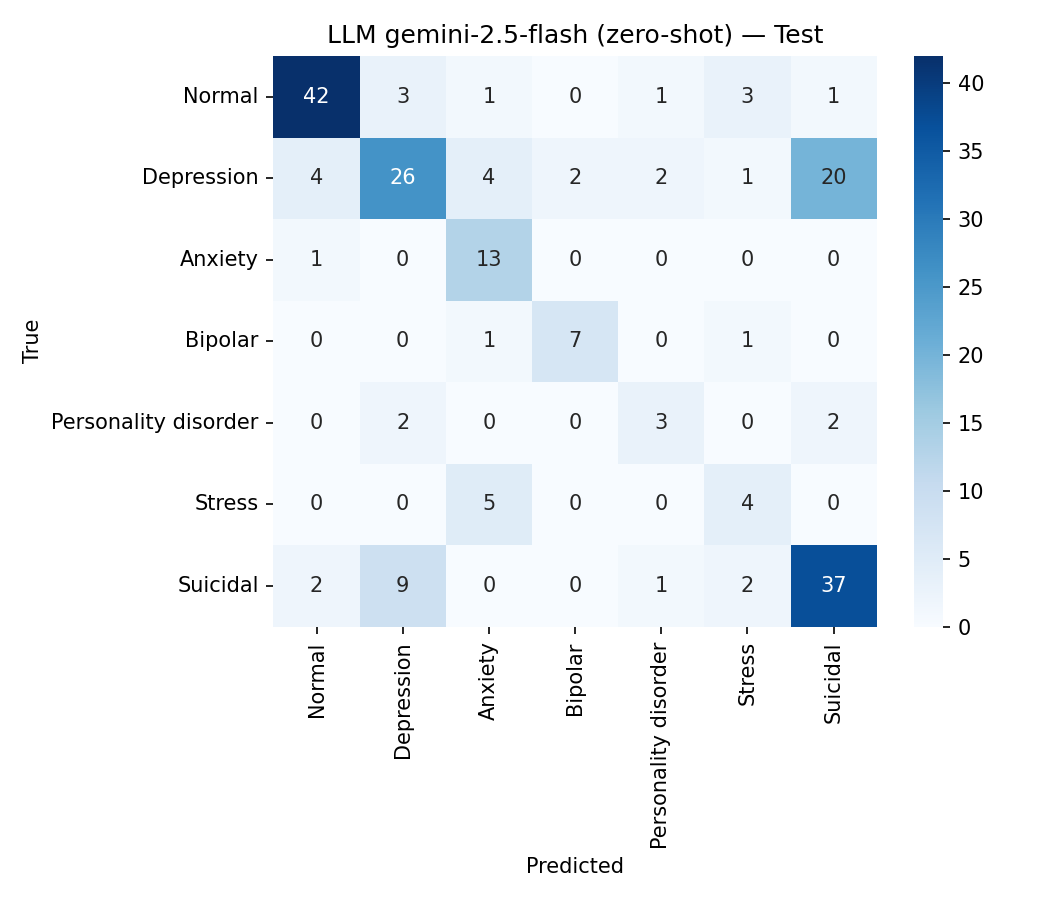

In [28]:
from IPython.display import Image

cm_path = artifacts_dir / "llm_confusion_matrix.png"
if cm_path.exists():
    display(Image(filename=str(cm_path), width=700))
else:
    print("llm_confusion_matrix.png chưa được tạo.")

## 10. Tóm tắt kết quả và bước tiếp theo

In [29]:
from IPython.display import HTML
from datetime import datetime

if metrics_path.exists():
    with open(metrics_path) as f:
        m = json.load(f)

    html = f"""
    <div style="border:1px solid #4CAF50; border-radius:8px; padding:16px; font-family:monospace; background:#000000;">
    <h3 style="color:#2E7D32;">M5 Hoàn thành — {datetime.now().strftime('%Y-%m-%d %H:%M')}</h3>
    <table style="border-collapse:collapse; width:100%;">
      <tr><td style="padding:4px 12px;"><b>Model</b></td><td>{m.get('model', cfg['generation']['model'])}</td></tr>
      <tr style="background:#879797;"><td style="padding:4px 12px;"><b>Mode</b></td><td>{m.get('prompting_mode', PROMPTING_MODE)}</td></tr>
      <tr><td style="padding:4px 12px;"><b>Accuracy</b></td><td>{m['accuracy']:.4f}</td></tr>
      <tr style="background:#879797;"><td style="padding:4px 12px;"><b>Macro F1</b></td><td>{m['macro_f1']:.4f}</td></tr>
      <tr><td style="padding:4px 12px;"><b>Weighted F1</b></td><td>{m['weighted_f1']:.4f}</td></tr>
    </table>
    <br/>
    <b>Artifacts đã lưu:</b>
    <ul>
      <li>data/artifacts/llm_predictions.jsonl</li>
      <li>data/artifacts/llm_metrics.json</li>
      <li>data/artifacts/llm_cost_report.json</li>
      <li>data/artifacts/llm_confusion_matrix.png</li>
    </ul>
    <b>Bước tiếp theo:</b> Chạy <code>scripts/run_semantic_analysis.py</code> (M6)
    </div>
    """
    display(HTML(html))
else:
    print("Chạy các cell trên để có kết quả.")

Model,gemini-2.5-flash
Mode,zero_shot
Accuracy,0.6600
Macro F1,0.6175
Weighted F1,0.6550
